# Email Spam Detection System

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Free":[1,1,0,0,1,0,1,0],
    "Offer":[1,1,0,0,1,0,0,0],
    "Money":[1,0,0,0,1,0,1,0],
    "Urgent":[1,1,0,0,0,0,1,0],
    "Spam":[1,1,0,0,1,0,1,0]
}

df = pd.DataFrame(data)
df

,Free,Offer,Money,Urgent,Spam
0,1,1,1,1,1
1,1,1,0,1,1
2,0,0,0,0,0
3,0,0,0,0,0
4,1,1,1,0,1
5,0,0,0,0,0
6,1,0,1,1,1
7,0,0,0,0,0


In [4]:
X = df[["Free","Offer","Money","Urgent"]]
y = df["Spam"]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[3.,3.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.5e-10
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Free','Offer','Money','Urgent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 4)","[[0. ,0. ,0. ,0. ], [1. ,0.67,1. ,0.67]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 4)","[[0. ,0. ,0. ,0. ], [0. ,0.22,0. ,0.22]]"


In [8]:
new_email = pd.DataFrame(
    [[1,1,0,1]],
    columns=["Free","Offer","Money","Urgent"]
)
prediction = model.predict(new_email)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("not Spam")

Spam Email


In [10]:
probability = model.predict_proba(new_email) * 100
print(probability)


[[  0. 100.]]


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print("Accuracy :", accuracy)

Accuracy : 100.0


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 1]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_accuracy = knn.score(X_test, y_test) * 100

nb_accuracy = model.score(X_test, y_test) * 100

print("Gaussian Naive Bayes Accuracy :", nb_accuracy)

print("KNN Accuracy :", knn_accuracy)

Gaussian Naive Bayes Accuracy : 100.0
KNN Accuracy : 100.0


In [16]:
if nb_accuracy > knn_accuracy:
    print("Gaussian Naive Bayes performs better.")
elif knn_accuracy > nb_accuracy:
    print("KNN performs better.")
else:
    print("Both models perform equally.")

Both models perform equally.


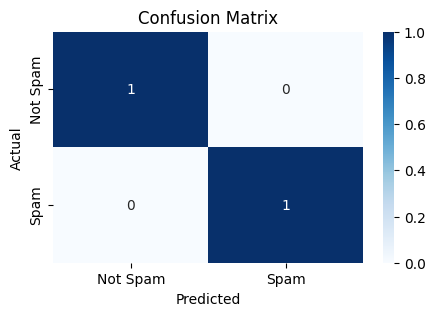

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam","Spam"],
    yticklabels=["Not Spam","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

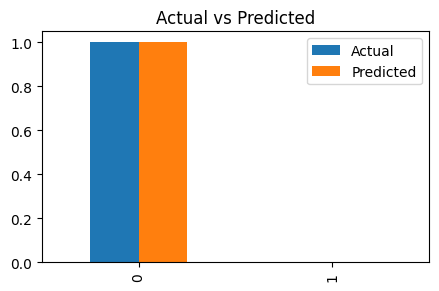

In [18]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.plot(kind="bar", figsize=(5,3))

plt.title("Actual vs Predicted")

plt.show()

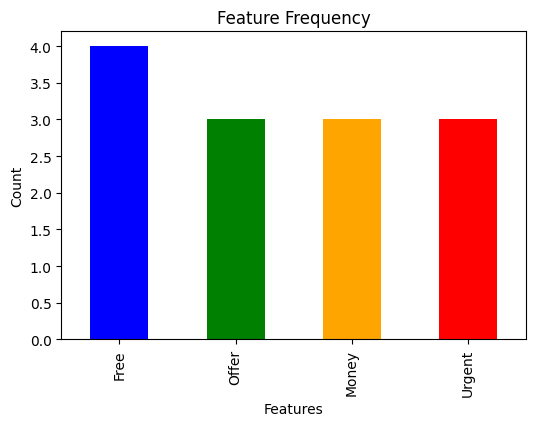

In [20]:
feature_count = X.sum()

feature_count.plot(
    kind="bar",
    figsize=(6,4),
    color=["blue","green","orange","red"]
)

plt.title("Feature Frequency")

plt.xlabel("Features")

plt.ylabel("Count")

plt.show()